# STTP-Net exp12 — Hybrid of Hybrids
### Pixel CutMix for Head/Median + Latent Mixup for Tail
### Best of both worlds — pixel mixing keeps nv/bkl strong, latent mixing keeps tail strong
> **Always: Restart Kernel → Run All Cells**

In [1]:
import os, random, warnings, json, sys
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── PATHS ──────────────────────────────────────────────────────────────────
BASE_DIR  = r'D:\class imbalance\date-16'
DATA_DIR  = os.path.join(BASE_DIR, 'data')
RAW_DIR   = os.path.join(DATA_DIR, 'raw')
IMAGE_DIR = os.path.join(RAW_DIR,  'images')
META_PATH = os.path.join(RAW_DIR,  'metadata.csv')
SPLIT_DIR = os.path.join(DATA_DIR, 'splits')
TRAIN_CSV = os.path.join(SPLIT_DIR, 'train.csv')
VAL_CSV   = os.path.join(SPLIT_DIR, 'val.csv')
TEST_CSV  = os.path.join(SPLIT_DIR, 'test.csv')
CACHE_DIR = os.path.join(DATA_DIR,  'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 16
NUM_WORKERS    = 0
ENCODER_DIM    = 512
LATENT_DIM     = 128
NUM_CLASSES    = 7
LR             = 3e-4
WEIGHT_DECAY   = 1e-4
EPOCHS_WARMUP  = 15
EPOCHS_PHASE1  = 20
EPOCHS_PHASE2  = 10
TEMPERATURE    = 0.07
CVAE_BETA      = 0.5
GRAD_CLIP      = 2.0
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASS_NAMES  = ['nv','mel','bkl','bcc','akiec','vasc','df']
LABEL2IDX    = {c:i for i,c in enumerate(CLASS_NAMES)}
IDX2LABEL    = {i:c for c,i in LABEL2IDX.items()}
HEAD_THRESH  = 1000
TAIL_THRESH  = 500
COLORS       = {'head':'#2ecc71','median':'#f39c12','tail':'#e74c3c'}

print(f'Device : {DEVICE}')
print(f'GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print('Constants loaded.')


Device : cuda
GPU    : NVIDIA GeForce RTX 5050 Laptop GPU
Constants loaded.


In [2]:
def load_splits():
    if os.path.exists(TRAIN_CSV):
        tr = pd.read_csv(TRAIN_CSV)
        va = pd.read_csv(VAL_CSV)
        te = pd.read_csv(TEST_CSV)
    else:
        from sklearn.model_selection import train_test_split
        meta = pd.read_csv(META_PATH)
        tr, tmp = train_test_split(meta, test_size=0.30, stratify=meta['dx'], random_state=SEED)
        va, te  = train_test_split(tmp,  test_size=0.50, stratify=tmp['dx'],  random_state=SEED)
        os.makedirs(SPLIT_DIR, exist_ok=True)
        tr.to_csv(TRAIN_CSV, index=False)
        va.to_csv(VAL_CSV,   index=False)
        te.to_csv(TEST_CSV,  index=False)
    for df in [tr, va, te]:
        if 'label_idx' not in df.columns:
            df['label_idx'] = df['dx'].map(LABEL2IDX)
    print(f'train={len(tr)}, val={len(va)}, test={len(te)}')
    return tr, va, te

train_df, val_df, test_df = load_splits()

class_counts  = Counter(train_df['dx'])
CLASS_GROUPS  = {c:('head'   if class_counts[c] >  HEAD_THRESH else
                    'tail'   if class_counts[c] <  TAIL_THRESH else
                    'median') for c in CLASS_NAMES}
TAIL_CLASSES   = [c for c,g in CLASS_GROUPS.items() if g=='tail']
MEDIAN_CLASSES = [c for c,g in CLASS_GROUPS.items() if g=='median']
HEAD_CLASSES   = [c for c,g in CLASS_GROUPS.items() if g=='head']
print('Class groups:', CLASS_GROUPS)
print('Tail classes:', TAIL_CLASSES)


train=8012, val=1001, test=1002
Class groups: {'nv': 'head', 'mel': 'median', 'bkl': 'median', 'bcc': 'tail', 'akiec': 'tail', 'vasc': 'tail', 'df': 'tail'}
Tail classes: ['bcc', 'akiec', 'vasc', 'df']


In [3]:
def _img_path(image_id):
    for ext in ('.jpg','.jpeg','.png'):
        p = os.path.join(IMAGE_DIR, image_id + ext)
        if os.path.exists(p): return p
    raise FileNotFoundError(f'Image not found: {image_id}')

cache_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

def build_cache(df, split_name):
    path = os.path.join(CACHE_DIR, f'{split_name}.pt')
    if os.path.exists(path):
        try:
            d = torch.load(path, map_location='cpu')
            assert 'images' in d and 'labels' in d
            print(f'{split_name} cache OK ({len(d["labels"])} samples)')
            return
        except:
            print(f'{split_name} cache stale — rebuilding...')
            os.remove(path)
    imgs, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Caching {split_name}'):
        img = Image.open(_img_path(row['image_id'])).convert('RGB')
        imgs.append(cache_tf(img))
        labels.append(int(row['label_idx']))
    torch.save({'images': torch.stack(imgs),
                'labels': torch.tensor(labels)}, path)
    print(f'{split_name} cached: {len(imgs)} samples')

for split, df in [('train',train_df),('val',val_df),('test',test_df)]:
    build_cache(df, split)
print('All caches ready.')


train cache OK (8012 samples)
val cache OK (1001 samples)
test cache OK (1002 samples)
All caches ready.


In [4]:
# No ToTensor in transforms — cache already stores float tensors
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.15, contrast=0.15,
                           saturation=0.15, hue=0.02),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
eval_transform = transforms.Compose([
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class CachedHAMDataset(Dataset):
    def __init__(self, split_name, transform=None):
        data = torch.load(os.path.join(CACHE_DIR, f'{split_name}.pt'),
                          map_location='cpu')
        self.imgs      = data['images']   # (N,3,224,224) float [0,1]
        self.labels    = data['labels']
        self.transform = transform

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img   = self.imgs[idx].clone()   # float tensor [0,1]
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)    # direct tensor transform — no PIL
        return img, label

train_ds = CachedHAMDataset('train', transform=train_transform)
val_ds   = CachedHAMDataset('val',   transform=eval_transform)
test_ds  = CachedHAMDataset('test',  transform=eval_transform)
print(f'train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')


train=8012, val=1001, test=1002


In [5]:
def instance_sampler(df):
    return WeightedRandomSampler(torch.ones(len(df)), len(df), replacement=True)

def median_sampler(df):
    counts   = df['dx'].value_counts().to_dict()
    median_n = sorted(counts.values())[len(counts)//2]
    w = np.clip(median_n / df['dx'].map(counts).values.astype(float), 1.0, 5.0)
    return WeightedRandomSampler(torch.tensor(w, dtype=torch.float), len(df), replacement=True)

def reverse_sampler(df):
    counts   = df['dx'].value_counts().to_dict()
    freq     = df['dx'].map(counts).values.astype(float)
    w        = np.clip(1.0/freq, 0, 8)
    # Boost mel specifically — clinically most important median class
    mel_mask = df['dx'].values == 'mel'
    w[mel_mask] *= 2.0
    w = w / w.sum() * len(w)
    return WeightedRandomSampler(torch.tensor(w, dtype=torch.float), len(df), replacement=True)

def make_loader(ds, sampler=None, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                      shuffle=(shuffle if sampler is None else False),
                      num_workers=NUM_WORKERS, pin_memory=True)

loader_instance = make_loader(train_ds, sampler=instance_sampler(train_df))
loader_median   = make_loader(train_ds, sampler=median_sampler(train_df))
loader_reverse  = make_loader(train_ds, sampler=reverse_sampler(train_df))
val_loader      = make_loader(val_ds)
test_loader     = make_loader(test_ds)
print('Samplers and loaders ready.')


Samplers and loaders ready.


In [6]:
class Encoder(nn.Module):
    def __init__(self, out_dim=ENCODER_DIM):
        super().__init__()
        bb    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        bb.fc = nn.Identity()
        self.backbone = bb
        self.proj = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, out_dim))

    def forward(self, x):
        return self.proj(self.backbone(x))

print('Encoder defined.')


Encoder defined.


In [7]:
class CVAE(nn.Module):
    def __init__(self, feat_dim=ENCODER_DIM, lat_dim=LATENT_DIM, nc=NUM_CLASSES):
        super().__init__()
        self.lat_dim = lat_dim
        self.nc      = nc
        self.enc1    = nn.Linear(feat_dim + nc, 256)
        self.mu_fc   = nn.Linear(256, lat_dim)
        self.lv_fc   = nn.Linear(256, lat_dim)
        self.dec1    = nn.Linear(lat_dim + nc, 256)
        self.dec_out = nn.Linear(256, feat_dim)

    def encode(self, f, y_oh):
        h = F.relu(self.enc1(torch.cat([f, y_oh], dim=-1)))
        return self.mu_fc(h), self.lv_fc(h)

    def decode(self, z, y_oh):
        return self.dec_out(F.relu(self.dec1(torch.cat([z, y_oh], dim=-1))))

    def forward(self, f, labels):
        y_oh      = F.one_hot(labels, self.nc).float().to(f.device)
        mu, lv    = self.encode(f, y_oh)
        z         = mu + torch.randn_like(mu) * (0.5 * lv).exp()
        return self.decode(z, y_oh), mu, lv, z

def cvae_loss(recon, orig, mu, lv, beta=CVAE_BETA):
    return (F.mse_loss(recon, orig) +
            beta * (-0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())))

print('CVAE defined.')


CVAE defined.


In [8]:
class SupConLoss(nn.Module):
    def __init__(self, temp=TEMPERATURE):
        super().__init__()
        self.temp = temp

    def forward(self, features, labels):
        f    = F.normalize(features, dim=1)
        B    = f.size(0)
        mask = torch.eq(labels.unsqueeze(0),
                        labels.unsqueeze(1)).float().to(f.device)
        mask.fill_diagonal_(0)
        sim      = torch.mm(f, f.T) / self.temp
        sim      = sim - sim.max(dim=1, keepdim=True).values.detach()
        exp_sim  = torch.exp(sim)
        log_prob = sim - torch.log(
            exp_sim.sum(1, keepdim=True) - exp_sim.diagonal().unsqueeze(1) + 1e-8)
        n_pos = mask.sum(1).clamp(min=1)
        return -(mask * log_prob).sum(1).div(n_pos).mean()

print('SupConLoss defined.')


SupConLoss defined.


In [9]:
# ══════════════════════════════════════════════════════════════════════════
# HYBRID OF HYBRIDS — THE CORE RESEARCH CONTRIBUTION
# ══════════════════════════════════════════════════════════════════════════
#
# Head/Median (nv, mel, bkl) → Pixel-level CutMix BEFORE encoder
#   - Keeps spatial features intact
#   - Strong for classes with enough samples
#   - Applied on raw image tensors (3, 224, 224)
#
# Tail (bcc, akiec, vasc, df) → Latent Mixup AFTER CVAE encode
#   - Semantically meaningful interpolation in class-conditional space
#   - Better generalisation for rare classes with few samples
#   - Applied on z ∈ R^128
#
# ══════════════════════════════════════════════════════════════════════════

def pixel_cutmix(imgs, labels, alpha=1.0):
    """
    CutMix on pixel images for Head/Median classes.
    imgs   : (B, 3, 224, 224)
    labels : (B,)
    Returns mixed imgs, la, lb, lam_vec
    """
    B, C, H, W = imgs.shape
    perm     = torch.randperm(B, device=imgs.device)
    imgs_b   = imgs[perm]
    labels_b = labels[perm]
    lam      = float(np.random.beta(alpha, alpha))

    # Random bounding box
    cut_rat  = np.sqrt(1.0 - lam)
    cut_w    = int(W * cut_rat)
    cut_h    = int(H * cut_rat)
    cx       = np.random.randint(W)
    cy       = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    imgs_mixed = imgs.clone()
    imgs_mixed[:, :, y1:y2, x1:x2] = imgs_b[:, :, y1:y2, x1:x2]

    # Adjust lam by actual box area
    lam_adj  = 1.0 - (x2 - x1) * (y2 - y1) / (W * H)
    lam_vec  = torch.full((B,), lam_adj, device=imgs.device)

    return imgs_mixed, labels, labels_b, lam_vec


def latent_mixup(z, labels, alpha=0.4):
    """
    Mixup on latent z for Tail classes.
    z      : (B, LATENT_DIM)
    labels : (B,)
    Returns z_mixed, la, lb, lam_vec
    """
    B        = z.size(0)
    perm     = torch.randperm(B, device=z.device)
    z_b      = z[perm]
    labels_b = labels[perm]
    lam      = float(np.random.beta(alpha, alpha))
    z_mixed  = lam * z + (1 - lam) * z_b
    lam_vec  = torch.full((B,), lam, device=z.device)
    return z_mixed, labels, labels_b, lam_vec

print('Pixel CutMix + Latent Mixup defined.')


Pixel CutMix + Latent Mixup defined.


In [10]:
class Head(nn.Module):
    def __init__(self, in_d=ENCODER_DIM, nc=NUM_CLASSES, drop=0.4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(in_d, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(drop * 0.5),
            nn.Linear(256, nc))

    def forward(self, x):
        return self.fc(x)


class STTPNet(nn.Module):
    """
    HYBRID OF HYBRIDS pipeline:

    TRAIN Head/Median batch:
      image → pixel_cutmix(image) → encoder → f_mixed → CVAE(f_mixed, y) → z
           → decode(z, y_interp) → head1

    TRAIN Tail batch:
      image → encoder → f → CVAE(f, y) → z → latent_mixup(z) → decode(z_mix, y_interp)
           → head2

    INFERENCE (no true label needed):
      image → encoder → f → pre_clf(f) → y_pred
           → CVAE(f, y_pred) → mu → decode(mu, y_pred) → head1 + head2 → fused
    """
    def __init__(self):
        super().__init__()
        self.encoder  = Encoder(ENCODER_DIM)
        self.cvae     = CVAE(ENCODER_DIM, LATENT_DIM, NUM_CLASSES)
        self.head1    = Head()   # head/median specialist
        self.head2    = Head()   # tail specialist
        self.sc_proj  = nn.Sequential(
            nn.Linear(ENCODER_DIM, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 128))
        self.pre_clf  = nn.Linear(ENCODER_DIM, NUM_CLASSES)

    def forward_head_median(self, imgs, labels, use_hm=True):
        """
        Head/Median path:
          pixel CutMix on image → encoder → CVAE → decode → head1
        """
        la, lb = labels, labels
        lam_vec = torch.ones(len(labels), device=imgs.device)

        if use_hm:
            # Step 1: pixel CutMix BEFORE encoder
            imgs_mix, la, lb, lam_vec = pixel_cutmix(imgs, labels)
        else:
            imgs_mix = imgs

        # Step 2: encode mixed image
        f          = self.encoder(imgs_mix)
        pre_logits = self.pre_clf(f)
        sc_feat    = self.sc_proj(f)

        # Step 3: CVAE with interpolated label conditioning
        if use_hm:
            lam_e    = lam_vec.unsqueeze(1)
            y_oh_la  = F.one_hot(la, NUM_CLASSES).float().to(imgs.device)
            y_oh_lb  = F.one_hot(lb, NUM_CLASSES).float().to(imgs.device)
            y_oh_mix = lam_e * y_oh_la + (1 - lam_e) * y_oh_lb
        else:
            y_oh_mix = F.one_hot(la, NUM_CLASSES).float().to(imgs.device)

        mu, lv   = self.cvae.encode(f, y_oh_mix)
        z        = mu + torch.randn_like(mu) * (0.5 * lv).exp()
        f_decode = self.cvae.decode(z, y_oh_mix)

        # CVAE recon on clean for ELBO
        f_clean    = self.encoder(imgs)
        y_oh_clean = F.one_hot(labels, NUM_CLASSES).float().to(imgs.device)
        mu_c, lv_c = self.cvae.encode(f_clean, y_oh_clean)
        z_c        = mu_c + torch.randn_like(mu_c) * (0.5 * lv_c).exp()
        f_recon    = self.cvae.decode(z_c, y_oh_clean)

        l1 = self.head1(f_decode)
        return l1, la, lb, lam_vec, sc_feat, mu_c, lv_c, pre_logits, f_recon, f_clean

    def forward_tail(self, imgs, labels, use_hm=True):
        """
        Tail path:
          encoder → CVAE → latent Mixup on z → decode → head2
        """
        # Step 1: encode clean image
        f          = self.encoder(imgs)
        pre_logits = self.pre_clf(f)

        # Step 2: CVAE encode
        y_oh = F.one_hot(labels, NUM_CLASSES).float().to(imgs.device)
        mu, lv = self.cvae.encode(f, y_oh)
        z      = mu + torch.randn_like(mu) * (0.5 * lv).exp()

        # CVAE recon for ELBO
        f_recon = self.cvae.decode(z, y_oh)

        la, lb  = labels, labels
        lam_vec = torch.ones(len(labels), device=imgs.device)

        if use_hm:
            # Step 3: Latent Mixup AFTER CVAE encode
            z_mix, la, lb, lam_vec = latent_mixup(z, labels)
            lam_e    = lam_vec.unsqueeze(1)
            y_oh_la  = F.one_hot(la, NUM_CLASSES).float().to(imgs.device)
            y_oh_lb  = F.one_hot(lb, NUM_CLASSES).float().to(imgs.device)
            y_oh_mix = lam_e * y_oh_la + (1 - lam_e) * y_oh_lb
            f_decode = self.cvae.decode(z_mix, y_oh_mix)
        else:
            f_decode = f_recon

        l2 = self.head2(f_decode)
        return l2, la, lb, lam_vec, mu, lv, pre_logits, f_recon, f

    @torch.no_grad()
    def fused_logits(self, imgs):
        """Inference — pre_clf predicts y, no true label needed."""
        self.eval()
        f       = self.encoder(imgs)
        y_pred  = self.pre_clf(f).argmax(1)
        y_oh    = F.one_hot(y_pred, NUM_CLASSES).float().to(imgs.device)
        mu, _   = self.cvae.encode(f, y_oh)
        f_recon = self.cvae.decode(mu, y_oh)
        l1 = self.head1(f_recon)
        l2 = self.head2(f_recon)
        w1 = self.head1.fc[-1].weight.norm()
        w2 = self.head2.fc[-1].weight.norm()
        return (l1 / w1 + l2 / w2) * 0.5

model = STTPNet().to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total:,}')

with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model.fused_logits(dummy)
print(f'Inference output shape: {out.shape}  ← should be (4, 7)')


Total parameters: 26,850,389
Inference output shape: torch.Size([4, 7])  ← should be (4, 7)


In [11]:
class EBSLoss(nn.Module):
    def __init__(self, counts):
        super().__init__()
        n = torch.tensor([float(counts.get(c, 1)) for c in CLASS_NAMES])
        self.register_buffer('log_n', torch.log(n))

    def forward(self, logits, labels):
        return F.cross_entropy(logits + self.log_n.to(logits.device), labels)

def mixed_ce(logits, la, lb, lam, ebs_fn):
    adj    = logits + ebs_fn.log_n.to(logits.device)
    lam    = lam.to(logits.device)
    loss_a = F.cross_entropy(adj, la.to(logits.device), reduction='none')
    loss_b = F.cross_entropy(adj, lb.to(logits.device), reduction='none')
    return (lam * loss_a + (1 - lam) * loss_b).mean()

ebs_fn  = EBSLoss(class_counts).to(DEVICE)
sup_con = SupConLoss().to(DEVICE)
print('Loss functions ready.')


Loss functions ready.


In [12]:
def train_epoch(model, opt, use_hm=True, warmup=False):
    model.train()
    total, n = 0.0, 0
    it_med = iter(loader_median)
    it_rev = iter(loader_reverse)

    for step, (imgs_i, lbl_i) in enumerate(loader_instance):
        try:    imgs_m, lbl_m = next(it_med)
        except: it_med = iter(loader_median);  imgs_m, lbl_m = next(it_med)
        try:    imgs_r, lbl_r = next(it_rev)
        except: it_rev = iter(loader_reverse); imgs_r, lbl_r = next(it_rev)

        imgs_i, lbl_i = imgs_i.to(DEVICE), lbl_i.to(DEVICE)
        imgs_m, lbl_m = imgs_m.to(DEVICE), lbl_m.to(DEVICE)
        imgs_r, lbl_r = imgs_r.to(DEVICE), lbl_r.to(DEVICE)

        opt.zero_grad()
        imgs_hm = torch.cat([imgs_i, imgs_m])
        lbl_hm  = torch.cat([lbl_i,  lbl_m])

        if warmup:
            # Warmup: train encoder + pre_clf + heads on clean features
            f_hm       = model.encoder(imgs_hm)
            pre_logits = model.pre_clf(f_hm)
            l1         = model.head1(f_hm)
            l2_w       = model.head2(model.encoder(imgs_r))
            loss_pre   = F.cross_entropy(pre_logits, lbl_hm)
            loss_h1    = ebs_fn(l1, lbl_hm)
            loss_h2    = ebs_fn(l2_w, lbl_r)
            loss       = loss_h1 + loss_h2 + 0.5 * loss_pre

        else:
            # ── Head/Median path: pixel CutMix → encoder → CVAE → head1 ──
            (l1, la_hm, lb_hm, lam_hm,
             sc_hm, mu_hm, lv_hm,
             pre_hm, f_recon_hm, f_hm) = model.forward_head_median(
                imgs_hm, lbl_hm, use_hm=use_hm)

            # ── Tail path: encoder → CVAE → latent Mixup → head2 ─────────
            (l2, la_r, lb_r, lam_r,
             mu_r, lv_r,
             pre_r, f_recon_r, f_r) = model.forward_tail(
                imgs_r, lbl_r, use_hm=use_hm)

            # ── Classification losses ──────────────────────────────────────
            if use_hm:
                loss_h1 = mixed_ce(l1, la_hm, lb_hm, lam_hm, ebs_fn)
                loss_h2 = mixed_ce(l2, la_r,  lb_r,  lam_r,  ebs_fn)
            else:
                loss_h1 = ebs_fn(l1, lbl_hm)
                loss_h2 = ebs_fn(l2, lbl_r)

            # ── nv-specific loss: reinforce head class recall ──────────────
            nv_mask = (lbl_hm == LABEL2IDX['nv'])
            loss_nv = (ebs_fn(l1[nv_mask], lbl_hm[nv_mask]) * 0.3
                       if nv_mask.any()
                       else torch.tensor(0.0, device=DEVICE))

            # ── CVAE ELBO ──────────────────────────────────────────────────
            loss_cvae = (cvae_loss(f_recon_hm, f_hm.detach(), mu_hm, lv_hm) +
                         cvae_loss(f_recon_r,  f_r.detach(),  mu_r,  lv_r)) * 0.5

            # ── SupCon on clean instance features ──────────────────────────
            loss_sc = sup_con(sc_hm[:len(lbl_i)], lbl_i)

            # ── pre_clf auxiliary loss ─────────────────────────────────────
            loss_pre = (F.cross_entropy(pre_hm, lbl_hm) +
                        F.cross_entropy(pre_r,  lbl_r)) * 0.5

            # ── Total loss ─────────────────────────────────────────────────
            loss = (loss_h1 + loss_h2
                    + 0.3 * loss_sc
                    + 0.2 * loss_cvae
                    + 0.3 * loss_pre
                    + loss_nv)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        total += loss.item(); n += 1

        if step % 50 == 0:
            print(f'  step {step}/{len(loader_instance)}'
                  f'  loss={loss.item():.4f}', flush=True)

    return total / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    for imgs, lbl in loader:
        p = model.fused_logits(imgs.to(DEVICE)).argmax(-1).cpu()
        preds.append(p); labels.append(lbl)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    return ((preds == labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels)


@torch.no_grad()
def evaluate_tta(model, loader, n_tta=5):
    model.eval()
    tta_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1,
                               saturation=0.1, hue=0.02),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    preds, labels, probs = [], [], []
    for imgs, lbl in tqdm(loader, desc='TTA', leave=False):
        bp = F.softmax(model.fused_logits(imgs.to(DEVICE)), -1).cpu()
        for _ in range(n_tta - 1):
            aug = torch.stack([tta_tf(t) for t in imgs])
            bp += F.softmax(model.fused_logits(aug.to(DEVICE)), -1).cpu()
        bp /= n_tta
        preds.append(bp.argmax(-1)); labels.append(lbl); probs.append(bp)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    return ((preds == labels).mean(),
            balanced_accuracy_score(labels, preds),
            preds, labels, probs)

print('Train / eval functions ready.')


Train / eval functions ready.


In [13]:
EXP_NAME  = 'exp12_hybrid_of_hybrids'
EXP_DIR   = os.path.join(BASE_DIR, 'experiments', EXP_NAME)
os.makedirs(EXP_DIR, exist_ok=True)
best_ckpt = os.path.join(EXP_DIR, 'best_model.pt')

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
TOTAL_EPOCHS = EPOCHS_WARMUP + EPOCHS_PHASE1 + EPOCHS_PHASE2
scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6)

history  = {'epoch':[], 'loss':[], 'val_acc':[], 'val_bal':[], 'phase':[]}
best_bal = 0.0

print('=' * 65, flush=True)
print(f'Warmup     : {EPOCHS_WARMUP} epochs  [encoder + pre_clf stabilisation]', flush=True)
print(f'Phase 1    : {EPOCHS_PHASE1} epochs  [Pixel CutMix (head/median) + Latent Mixup (tail)]', flush=True)
print(f'Phase 2    : {EPOCHS_PHASE2} epochs  [Boundary refinement, no mixing]', flush=True)
print(f'Total      : {TOTAL_EPOCHS} epochs', flush=True)
print('=' * 65, flush=True)

for epoch in range(1, TOTAL_EPOCHS + 1):
    if   epoch <= EPOCHS_WARMUP:
        phase, warmup, use_hm = 'Warmup',     True,  False
    elif epoch <= EPOCHS_WARMUP + EPOCHS_PHASE1:
        phase, warmup, use_hm = 'HybridMix',  False, True
    else:
        phase, warmup, use_hm = 'Refinement', False, False

    loss           = train_epoch(model, optimizer, use_hm=use_hm, warmup=warmup)
    acc, bal, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['epoch'].append(epoch)
    history['loss'].append(loss)
    history['val_acc'].append(acc)
    history['val_bal'].append(bal)
    history['phase'].append(phase)

    print(f'[{phase:10s}] Ep {epoch:03d}/{TOTAL_EPOCHS}  '
          f'loss={loss:.4f}  val_acc={acc:.4f}  val_bacc={bal:.4f}', flush=True)
    sys.stdout.flush()

    if bal > best_bal:
        best_bal = bal
        torch.save(model.state_dict(), best_ckpt)
        print(f'  *** best val_bacc={best_bal:.4f} saved ***', flush=True)

print(f'\nDone. Best val balanced acc: {best_bal:.4f}', flush=True)


Warmup     : 15 epochs  [encoder + pre_clf stabilisation]
Phase 1    : 20 epochs  [Pixel CutMix (head/median) + Latent Mixup (tail)]
Phase 2    : 10 epochs  [Boundary refinement, no mixing]
Total      : 45 epochs
  step 0/501  loss=5.0139
  step 50/501  loss=2.5585
  step 100/501  loss=2.4272
  step 150/501  loss=1.5660
  step 200/501  loss=1.5692
  step 250/501  loss=1.4881
  step 300/501  loss=1.4254
  step 350/501  loss=1.4049
  step 400/501  loss=1.5092
  step 450/501  loss=1.2966
  step 500/501  loss=1.2908
[Warmup    ] Ep 001/45  loss=1.7563  val_acc=0.1099  val_bacc=0.1444
  *** best val_bacc=0.1444 saved ***
  step 0/501  loss=1.4826
  step 50/501  loss=0.9438
  step 100/501  loss=0.8052
  step 150/501  loss=0.8495
  step 200/501  loss=1.4045
  step 250/501  loss=0.7479
  step 300/501  loss=1.0385
  step 350/501  loss=1.3615
  step 400/501  loss=0.8159
  step 450/501  loss=1.4176
  step 500/501  loss=1.0213
[Warmup    ] Ep 002/45  loss=1.1179  val_acc=0.1099  val_bacc=0.1429
  

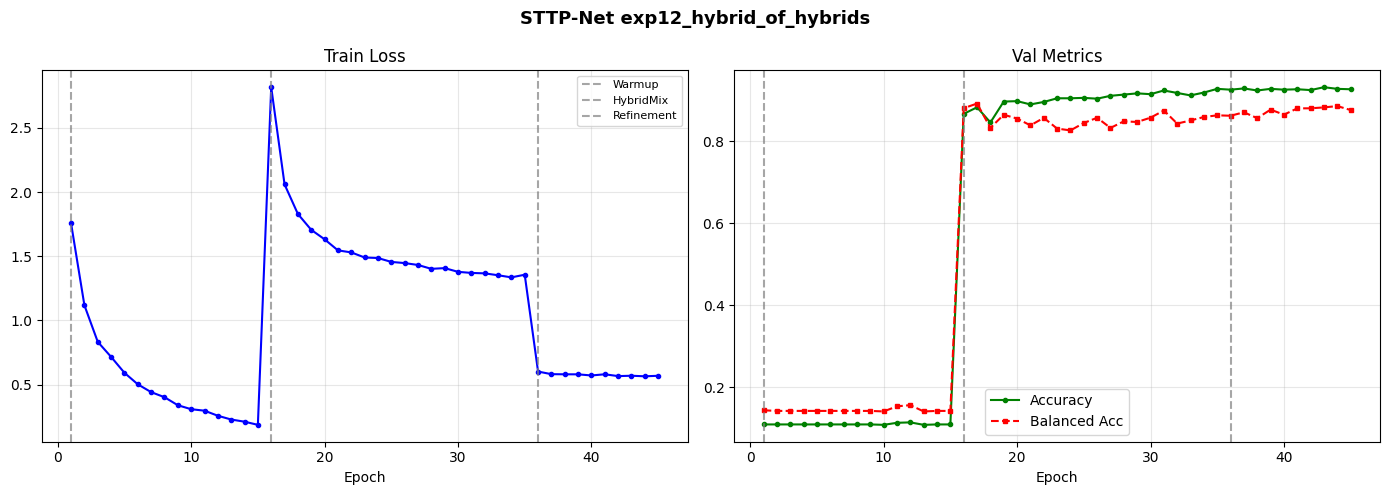

Training curves saved.


In [14]:
phase_boundaries = {}
for ep, ph in zip(history['epoch'], history['phase']):
    if ph not in phase_boundaries:
        phase_boundaries[ph] = ep

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['epoch'], history['loss'], 'b-o', ms=3)
for ph, ep in phase_boundaries.items():
    axes[0].axvline(ep, color='gray', ls='--', alpha=0.7, label=ph)
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['val_acc'], 'g-o',  ms=3, label='Accuracy')
axes[1].plot(history['epoch'], history['val_bal'], 'r--s', ms=3, label='Balanced Acc')
for ph, ep in phase_boundaries.items():
    axes[1].axvline(ep, color='gray', ls='--', alpha=0.7)
axes[1].set_title('Val Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'STTP-Net {EXP_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'training_curves.png'), dpi=150)
plt.show()
print('Training curves saved.')


In [15]:
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
print('Best model loaded.')

# Single pass
test_acc, test_bal, test_preds, test_labels = evaluate(model, test_loader)
print(f'\nTest Accuracy          : {test_acc:.4f}')
print(f'Test Balanced Accuracy : {test_bal:.4f}\n')
print(classification_report(test_labels, test_preds,
                             target_names=CLASS_NAMES, digits=4))


Best model loaded.

Test Accuracy          : 0.8832
Test Balanced Accuracy : 0.8679

              precision    recall  f1-score   support

          nv     0.9657    0.9225    0.9436       671
         mel     0.7034    0.7411    0.7217       112
         bkl     0.8485    0.7636    0.8038       110
         bcc     0.7705    0.9038    0.8319        52
       akiec     0.5577    0.9062    0.6905        32
        vasc     0.9286    0.9286    0.9286        14
          df     0.5882    0.9091    0.7143        11

    accuracy                         0.8832      1002
   macro avg     0.7661    0.8679    0.8049      1002
weighted avg     0.8957    0.8832    0.8868      1002



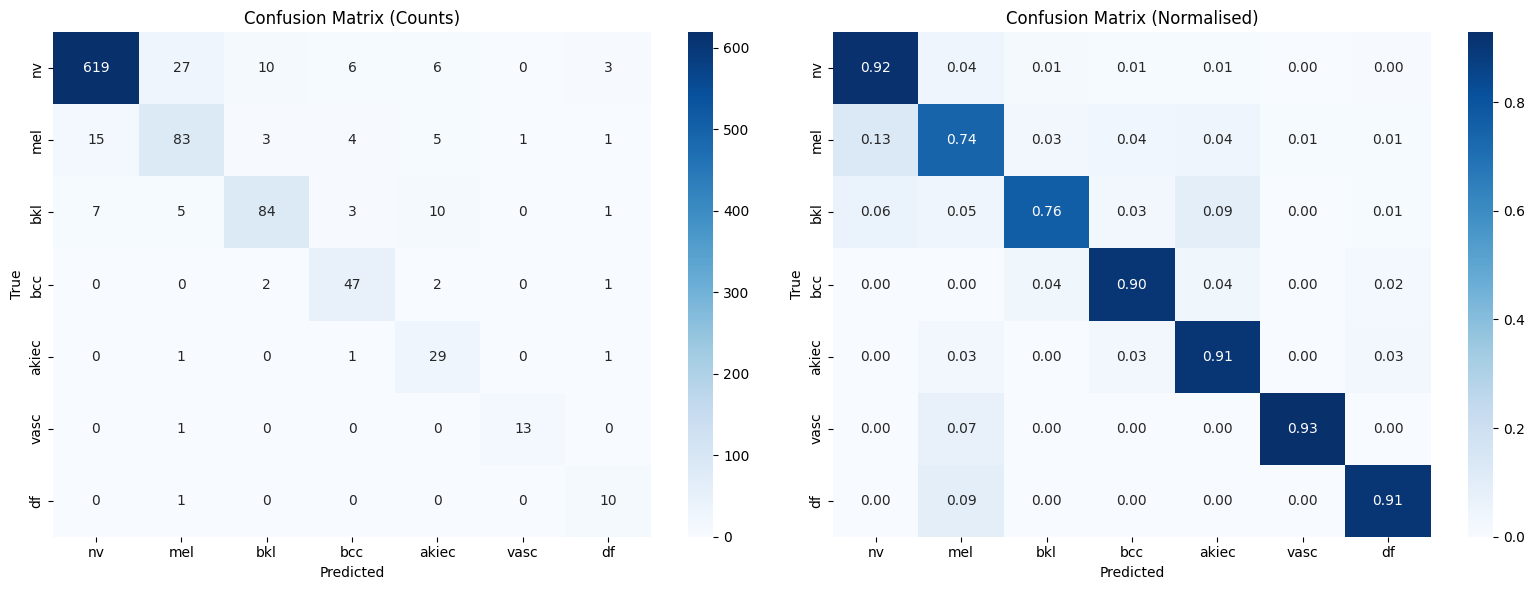

In [17]:
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype(float) / cm.sum(1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()


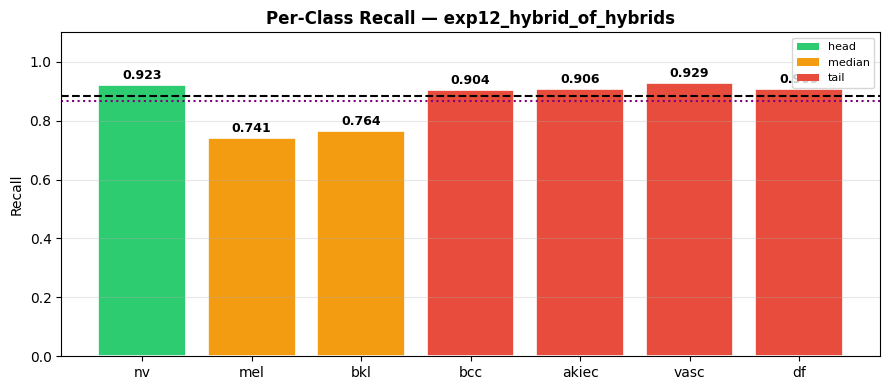

In [18]:
recalls = [cm[i,i]/cm[i].sum() if cm[i].sum()>0 else 0
           for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASS_NAMES, recalls,
              color=[COLORS[CLASS_GROUPS[c]] for c in CLASS_NAMES],
              edgecolor='white', linewidth=1.2)
ax.axhline(test_acc, color='black',  ls='--', lw=1.5,
           label=f'Overall  ({test_acc:.3f})')
ax.axhline(test_bal, color='purple', ls=':',  lw=1.5,
           label=f'Balanced ({test_bal:.3f})')
for bar, r in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{r:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_ylabel('Recall')
ax.set_title(f'Per-Class Recall — {EXP_NAME}', fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=COLORS[g], label=g) for g in ['head','median','tail']]
ax.legend(handles=legend_els, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'per_class_recall.png'), dpi=150)
plt.show()


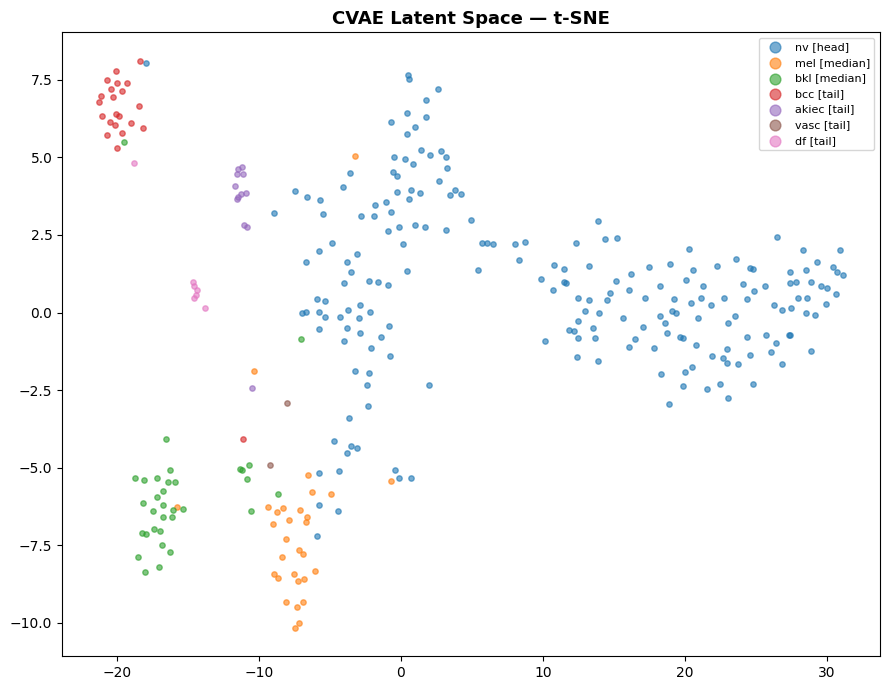

t-SNE saved.


In [19]:
try:
    from sklearn.manifold import TSNE
    model.eval()
    zs, ls = [], []
    with torch.no_grad():
        for i, (imgs, lbl) in enumerate(val_loader):
            if i >= 20: break
            f    = model.encoder(imgs.to(DEVICE))
            y_oh = F.one_hot(lbl.to(DEVICE), NUM_CLASSES).float()
            mu, _ = model.cvae.encode(f, y_oh)
            zs.append(mu.cpu().numpy())
            ls.append(lbl.numpy())
    zs = np.concatenate(zs); ls = np.concatenate(ls)
    emb = TSNE(n_components=2, perplexity=30,
               random_state=SEED, max_iter=1000).fit_transform(zs)
    fig, ax = plt.subplots(figsize=(9, 7))
    cmap = plt.get_cmap('tab10')
    for i, cls in IDX2LABEL.items():
        m = ls == i
        ax.scatter(emb[m,0], emb[m,1],
                   label=f'{cls} [{CLASS_GROUPS[cls]}]',
                   alpha=0.6, s=15, color=cmap(i))
    ax.set_title('CVAE Latent Space — t-SNE', fontsize=13, fontweight='bold')
    ax.legend(markerscale=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(EXP_DIR, 'tsne_latent.png'), dpi=150)
    plt.show()
    print('t-SNE saved.')
except Exception as e:
    print(f't-SNE skipped: {e}')


In [20]:
results = {
    'exp_name'               : EXP_NAME,
    'test_accuracy'          : round(float(test_acc), 4),
    'test_balanced_accuracy' : round(float(test_bal), 4),
    'best_val_balanced_acc'  : round(float(best_bal), 4),
    'architecture'           : 'ResNet50+CVAE+SupCon+HybridOfHybrids+DualHead+EBS+preclf',
    'mixing_strategy': {
        'head_median': 'Pixel CutMix on image before encoder',
        'tail'       : 'Latent Mixup on z after CVAE encode',
    },
    'inference': 'pre_clf(f)->y_pred->CVAE(f,y_pred)->decode->fused heads',
    'phases': {
        'warmup'  : f'{EPOCHS_WARMUP} epochs',
        'phase1'  : f'{EPOCHS_PHASE1} epochs HybridMix ON',
        'phase2'  : f'{EPOCHS_PHASE2} epochs refinement',
    },
    'vs_baselines': {
        'exp06_pixel_cutmix'     : {'acc': 0.9102, 'bal': 0.8764},
        'exp11_latent_mixup'     : {'acc': 0.8792, 'bal': 0.8701},
        'exp12_hybrid_of_hybrids': {'acc': round(float(test_acc),4),
                                    'bal': round(float(test_bal),4)},
    }
}
path = os.path.join(EXP_DIR, 'results_summary.json')
with open(path, 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved.')
print(json.dumps(results, indent=2))


Results saved.
{
  "exp_name": "exp12_hybrid_of_hybrids",
  "test_accuracy": 0.8832,
  "test_balanced_accuracy": 0.8679,
  "best_val_balanced_acc": 0.8922,
  "architecture": "ResNet50+CVAE+SupCon+HybridOfHybrids+DualHead+EBS+preclf",
  "mixing_strategy": {
    "head_median": "Pixel CutMix on image before encoder",
    "tail": "Latent Mixup on z after CVAE encode"
  },
  "inference": "pre_clf(f)->y_pred->CVAE(f,y_pred)->decode->fused heads",
  "phases": {
    "warmup": "15 epochs",
    "phase1": "20 epochs HybridMix ON",
    "phase2": "10 epochs refinement"
  },
  "vs_baselines": {
    "exp06_pixel_cutmix": {
      "acc": 0.9102,
      "bal": 0.8764
    },
    "exp11_latent_mixup": {
      "acc": 0.8792,
      "bal": 0.8701
    },
    "exp12_hybrid_of_hybrids": {
      "acc": 0.8832,
      "bal": 0.8679
    }
  }
}
